In [3]:
import pandas as pd
path = '/Users/baharehfatemi/Desktop/demokratibasen/Data/eval/gemma-2-9b-checkpoint-9000-inputs-refs-preds-examples_2500.jsonl'

In [ ]:
!pip install google-generativeai

In [27]:
data = pd.read_json(path, lines=True)

In [28]:
data.columns

Index(['input_text', 'prompt', 'reference', 'prediction'], dtype='object')

420269
4120.8912


<Axes: >

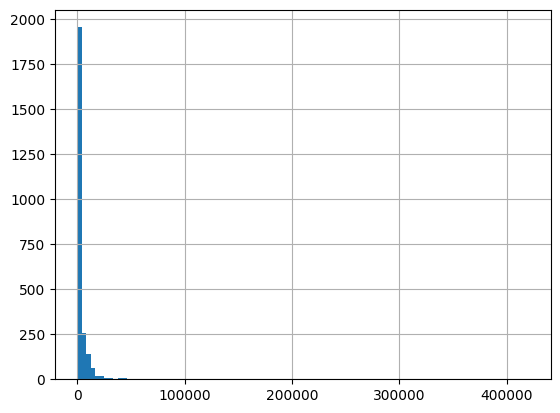

In [29]:
#max length of input_text
print (data['input_text'].str.len().max())

#avg length of input_text
print (data['input_text'].str.len().mean() )

#histogram of input_text length with bins of 100
data['input_text'].str.len().hist(bins=100)




In [31]:
#number of input_text with length greater than 1000
print (data[data['input_text'].str.len() > 50000].shape[0]) 

#drop the input_text with length greater than 50000
data = data[data['input_text'].str.len() <= 50000]



0


<Axes: >

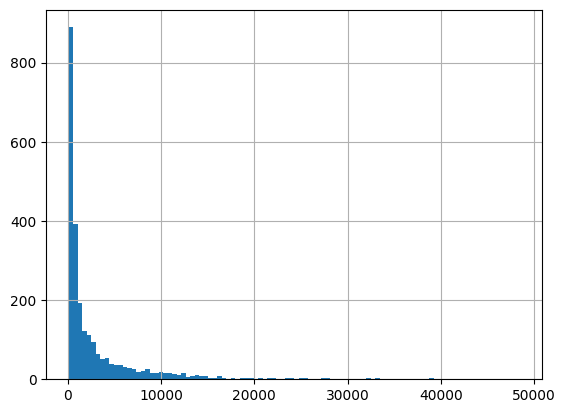

In [32]:
#histogram of input_text length with bins of 100
data['input_text'].str.len().hist(bins=100)

In [44]:
import os
import google.generativeai as genai

API_KEY = os.environ.get("GOOGLE_API_KEY") or os.environ.get("GEMINI_API_KEY")
GEMINI_MODEL = "gemini-2.5-flash"

genai.configure(api_key=API_KEY)
model = genai.GenerativeModel(GEMINI_MODEL)
text = "Hello, how many tokens is this?"
response = model.count_tokens(text)
print(f"Token count: {response.total_tokens}")




Token count: 8


In [50]:
def count_tokens(text):
    response = model.count_tokens(text)
    print(f"Token count: {response.total_tokens}")

count_tokens(data['input_text'][4])

Token count: 1392
